# Trabajo Práctico N°1
## Problema 3: Regresión

Integrantes: Sebastian Palacio, Juana Chies Doumecq

**Objetivo:**

Construir un modelo de red neuronal que prediga el valor numérico de la rentabilidad (Profit) de una transacción comercial a partir de las características del pedido.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import copy

from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import KNNImputer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
base_path = os.path.join("datasets", "problema3")
df = pd.read_csv(os.path.join(base_path, 'Sample - Superstore.csv'), encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## 2. Análisis Exploratorio de Datos (EDA)

Exploramos el dataset para entender la distribución de la variable objetivo
Profit, identificar outliers, analizar las variables predictoras y decidir
qué columnas conservar o descartar antes del preprocesamiento.

### 2.1 Ingeniería de características

Las columnas `Order Date` y `Ship Date` no pueden usarse directamente como
entrada de un MLP. Extraemos de ellas el año, mes, día de la semana y trimestre,
y calculamos la demora de envío en días (`ship_delay`). Luego eliminamos las
fechas originales ya que toda su información útil quedó representada en las
nuevas columnas numéricas.

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

for col, prefix in [('Order Date', 'order'), ('Ship Date', 'ship')]:
    df[f'{prefix}_year']    = df[col].dt.year
    df[f'{prefix}_month']   = df[col].dt.month
    df[f'{prefix}_dow']     = df[col].dt.dayofweek
    df[f'{prefix}_quarter'] = df[col].dt.quarter

# Demora en días
df['ship_delay'] = (df['Ship Date'] - df['Order Date']).dt.days

# Eliminamos columnas de fecha originales
df.drop(columns=['Order Date', 'Ship Date'], inplace=True)

El dataset ahora tiene columnas temporales numéricas en lugar de fechas, las cuales almacenan la información útil de columnas anteriores.

In [ ]:
cols_to_drop = [
    'Row ID', 'Order ID', 'Customer ID',
    'Customer Name', 'Product ID', 'Product Name',
    'Country', 'City', 'Postal Code',
]

df.drop(columns=cols_to_drop, inplace=True)
print("Columnas tras ingeniería de características:")
print(df.columns.tolist())

Columnas tras feature engineering:
['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'order_year', 'order_month', 'order_dow', 'order_quarter', 'ship_year', 'ship_month', 'ship_dow', 'ship_quarter', 'ship_delay']


Se eliminaron columnas no predictivas: identificadores únicos (Row ID,
Order ID, Customer ID, Product ID), nombres textuales (Customer Name,
Product Name), y columnas de alta cardinalidad sin valor predictivo claro
(City, Postal Code). Country se eliminó porque es constante en todo
el dataset (todos los registros son de EE.UU.).

### 2.2 División train / validación / test

Dividimos los datos en tres conjuntos: train (64%), validación (16%) y test (20%).
La validación se usa durante el entrenamiento para monitorear el loss y aplicar
Early Stopping. El test se reserva exclusivamente para la evaluación final y
no influye en ninguna decisión de diseño del modelo.

El split se hace **antes** de cualquier escalado o codificación para evitar
data leakage: el scaler solo aprende los parámetros del train.

In [7]:
X = df.drop(columns='Profit')
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Validation size: {len(X_val)}")

Train size: 6396
Test size: 1999
Validation size: 1599


El dataset quedó dividido en 6.396 muestras para train,
1.599 para validación y 1.999 para test.

### 2.3 Visualización de variables numéricas

Graficamos boxplots e histogramas de las variables numéricas (Sales,
Quantity, Discount, Profit) para identificar outliers y entender
la distribución antes de escalar.

In [8]:
numerical_cols = ['Sales', 'Quantity', 'Discount']
show_num = X_train[numerical_cols].copy()
show_num['Profit'] = y_train.values

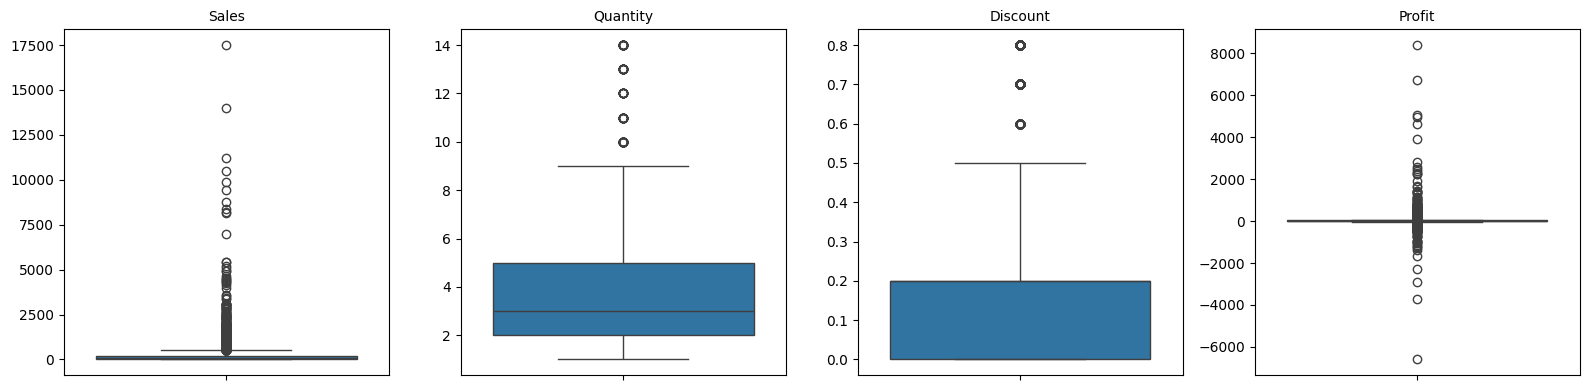

In [9]:
cols = 4 
num_vars = len(show_num.columns)
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, var in enumerate(show_num.columns): 
    sns.boxplot(
        data=show_num,
        y=var, 
        ax=axes[i]
    )
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Se muestra la distribución y los valores atípicos de las variables Sales, Quantity, Discount y Profit, evidenciando una gran dispersión y la presencia de datos extremos, especialmente en las categorías de Sales y Profit.

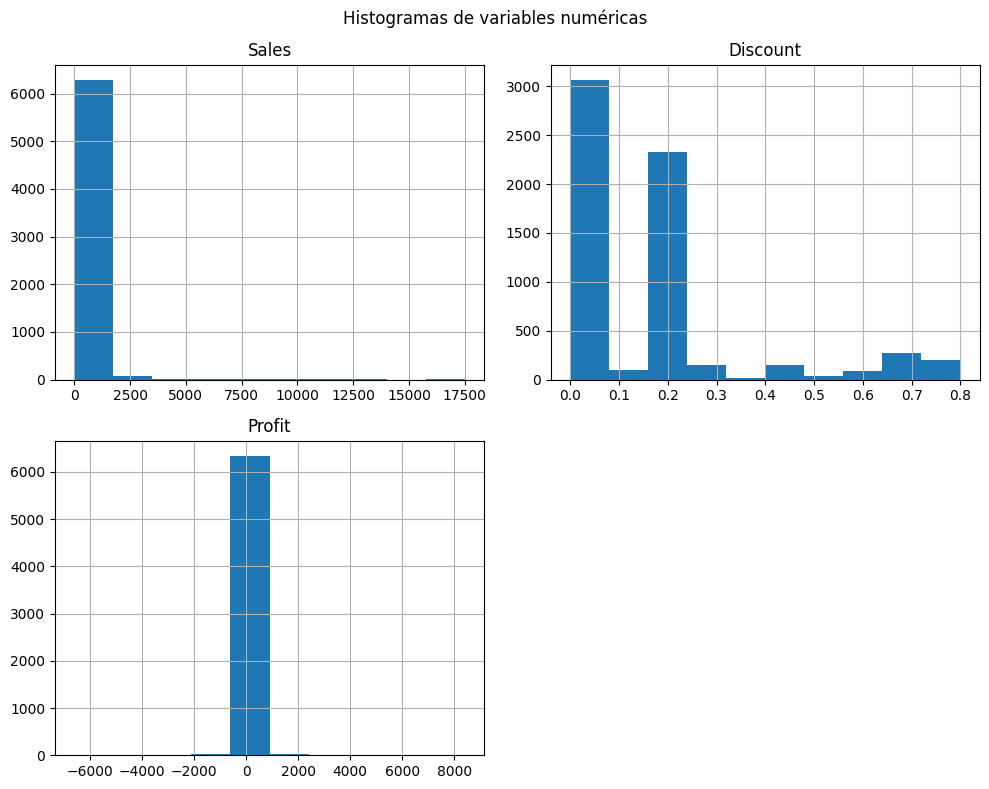

In [10]:
show_num[['Sales', 'Discount', 'Profit']].hist(figsize=(10,8))
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.show()

Profit tiene una distribución asimétrica con valores tanto positivos
como negativos (pérdidas). Sales y Discount tienen outliers marcados
hacia la derecha. Estos outliers son datos legítimos del negocio (ventas
grandes o descuentos altos) y no se eliminan: el modelo debe aprender
a predecir también esos casos.

C:\Users\Sebas\AppData\Local\Temp\ipykernel_29592\2638482559.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


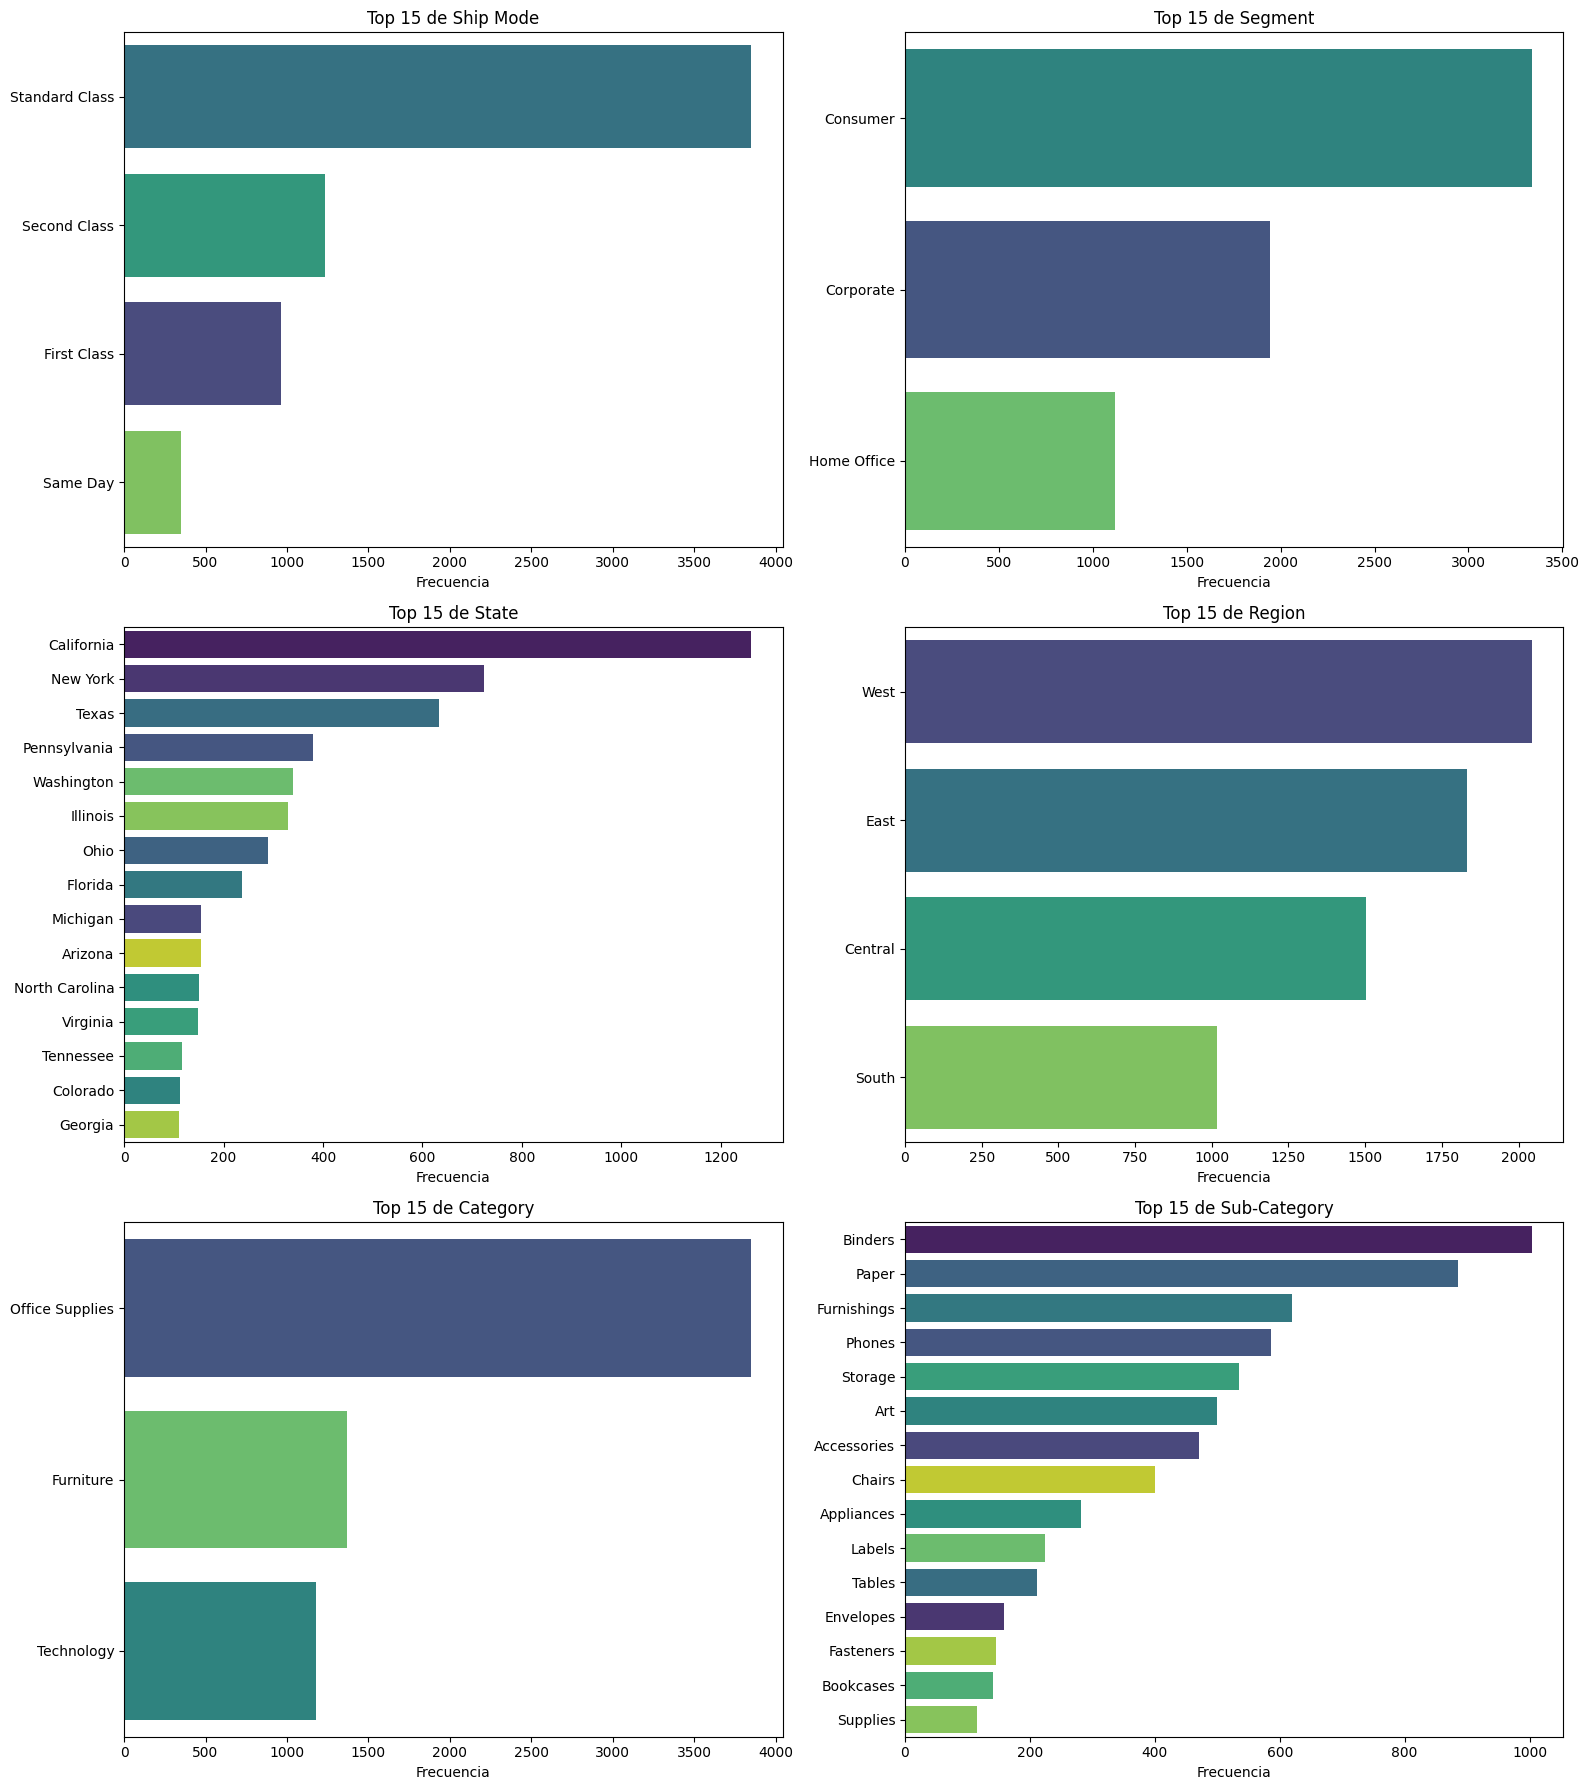

In [11]:
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
show_cat = X_train[categorical_cols].copy()

n_cols = 2 
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    top_n = show_cat[col].value_counts().head(15)
    
    sns.countplot(
        data=show_cat[show_cat[col].isin(top_n.index)], 
        y=col, 
        ax=axes[i], 
        order=top_n.index,
        palette='viridis',
        hue=col,
        legend=False
    )
    
    axes[i].set_title(f'Top 15 de {col}', fontsize=12)
    axes[i].set_xlabel('Frecuencia')
    axes[i].set_ylabel('')

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Se detalla la frecuencia de las variables categóricas, donde se destaca que el modo de envío Standard Class, el segmento Consumer y la categoría Office Supplies son los elementos con mayor volumen de actividad comercial.

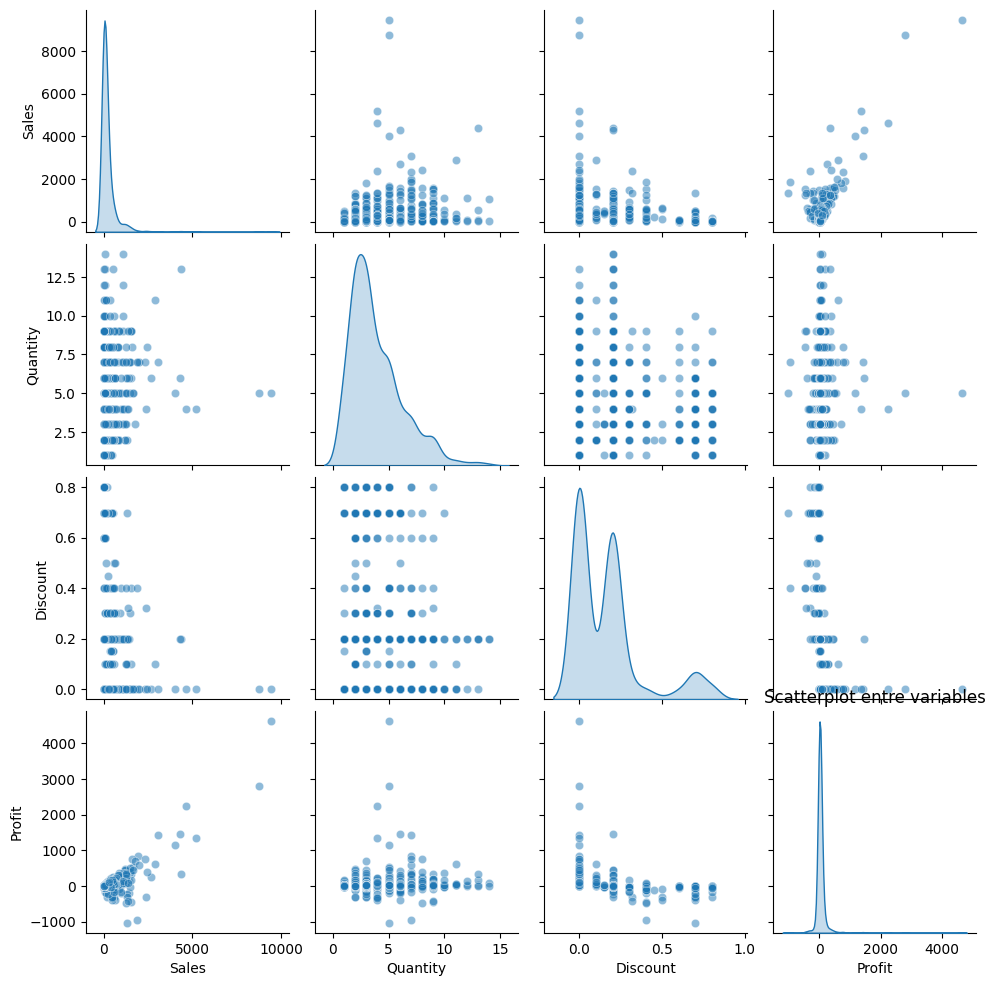

In [17]:
sns.pairplot(show_num.sample(1000, random_state=1), diag_kind='kde', plot_kws={'alpha': 0.5})
plt.title('Scatterplot entre variables')
plt.show()

Este gráfico de dispersión matricial muestra las correlaciones entre las variables numéricas, revelando una relación positiva notable entre Sales y Profit, así como la tendencia de los mayores descuentos a impactar negativamente en los márgenes de ganancia.

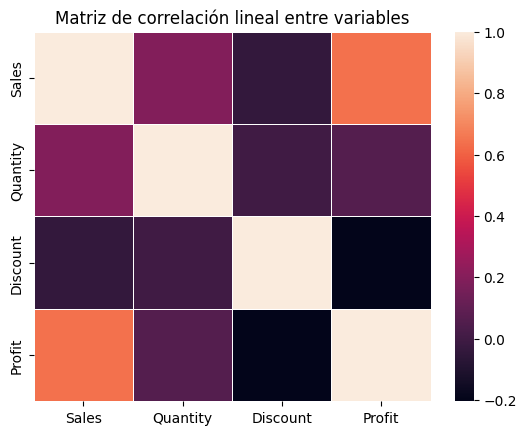

In [18]:
corrmat = show_num.corr()
sns.heatmap(corrmat, vmax=1, linewidths=.5)
plt.title('Matriz de correlación lineal entre variables')
plt.show()

Esta matriz de correlación visualiza la fuerza de las relaciones lineales entre las variables, confirmando que la asociación más fuerte y positiva se da entre Sales y Profit, mientras que el Discount presenta la correlación más negativa respecto a la rentabilidad.

### 2.4 Análisis de datos faltantes y outliers

Verificamos si existen valores nulos en el dataset y analizamos los
outliers identificados en las visualizaciones anteriores.

In [12]:
X_test.isna().sum()

Ship Mode        0
Segment          0
State            0
Region           0
Category         0
Sub-Category     0
Sales            0
Quantity         0
Discount         0
order_year       0
order_month      0
order_dow        0
order_quarter    0
ship_year        0
ship_month       0
ship_dow         0
ship_quarter     0
ship_delay       0
dtype: int64

El dataset no presenta valores nulos, por lo que no es necesaria ninguna
estrategia de imputación.

Respecto a los outliers en Sales y Profit: son datos legítimos del
negocio (ventas masivas a empresas o devoluciones que generan pérdidas
grandes). Eliminarlos haría que el modelo no aprenda a predecir esos
casos. En cambio, usamos RobustScaler para el escalado, que es
resistente a outliers al basarse en la mediana y el rango intercuartílico
en lugar de la media y el desvío estándar.

## 3. Preprocesamiento

### 3.1 Codificación de variables categóricas

Las variables categóricas no pueden ingresarse directamente al MLP.
Elegimos la técnica según la cardinalidad de cada variable:

- **One-Hot Encoding** para Ship Mode, Segment, Region, Category
  y Sub-Category: tienen baja cardinalidad (entre 2 y 17 valores únicos),
  por lo que crear una columna binaria por categoría no expande demasiado
  el dataset y no introduce orden artificial entre las categorías.

- **Target Encoding** para State: tiene cardinalidad media-alta (49 estados).
  Con OHE generaríamos 49 columnas dispersas. Target Encoding reemplaza cada
  estado por el promedio de Profit de ese estado en el train, capturando
  información predictiva en una sola columna. Se aplica con smoothing=10
  para evitar overfitting en estados con pocas muestras.

El Target Encoder se ajusta solo sobre el train y se aplica al val y test
para evitar data leakage.

In [13]:
ohe_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

te_cols = ['State']

# --- One-Hot Encoding ---
X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=False, dtype=float)
X_test  = pd.get_dummies(X_test,  columns=ohe_cols, drop_first=False, dtype=float)
X_val   = pd.get_dummies(X_val,   columns=ohe_cols, drop_first=False, dtype=float)

# --- Target Encoding ---
te = TargetEncoder(cols=te_cols, smoothing=10)
X_train[te_cols] = te.fit_transform(X_train[te_cols], y_train)
X_test[te_cols]  = te.transform(X_test[te_cols])
X_val[te_cols]   = te.transform(X_val[te_cols])

Las variables categóricas quedaron codificadas. El dataset pasó de tener
columnas de texto a ser completamente numérico.

### 3.2 Escalado de variables numéricas

Escalamos las variables numéricas continuas con RobustScaler, que usa
la mediana y el rango intercuartílico en lugar de la media y el desvío.
Esto lo hace resistente a los outliers presentes en Sales y Profit.

El scaler se ajusta **solo sobre el train** (fit_transform) y se aplica
al val y test (transform), evitando que información del test influya
en la normalización (data leakage).

Para y (Profit) también aplicamos RobustScaler por la misma razón:
el modelo aprende en el espacio escalado y al evaluar invertimos la
transformación con inverse_transform para obtener predicciones en dólares.

In [19]:
# Escalado de X
numeric_cols = [
    'Sales', 'Quantity', 'Discount', 'ship_delay',
    'order_year', 'order_month', 'order_dow', 'order_quarter',
    'ship_year', 'ship_month', 'ship_dow', 'ship_quarter',
    'State',
]

scaler_x = RobustScaler()
X_train[numeric_cols] = scaler_x.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler_x.transform(X_test[numeric_cols])
X_val[numeric_cols] = scaler_x.transform(X_val[numeric_cols])

X_train_np = X_train.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)


# Escalado de y
scaler_y = RobustScaler()
y_train_np = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel().astype(np.float32)
y_test_np  = scaler_y.transform(y_test.values.reshape(-1,1)).ravel().astype(np.float32)
y_val_np   = scaler_y.transform(y_val.values.reshape(-1,1)).ravel().astype(np.float32)

Todas las variables numéricas están ahora en una escala comparable.
Las variables binarias generadas por OHE (valores 0 y 1) no se escalan
ya que ya están en un rango acotado.

## 4. Diseño e implementación de la red neuronal

### 4.1 Arquitectura: capas, neuronas y activaciones

Diseñamos un MLP con 3 capas ocultas de tamaño decreciente: 128 → 64 → 32,
seguidas de una capa de salida con 1 neurona.

El tamaño decreciente fuerza al modelo a comprimir la información en
representaciones cada vez más abstractas. Empezamos en 128 porque el
dataset tiene una dimensionalidad moderada tras el preprocesamiento.

En capas ocultas usamos **ReLU**, que evita el problema del gradiente
desvanecido y es estándar para regresión con MLPs.

### 4.2 Capa de salida

La capa de salida tiene **1 neurona sin función de activación** (lineal).
En regresión no queremos acotar el rango de salida: el modelo debe poder
predecir cualquier valor real, incluyendo Profit negativo.

### 4.3 Regularización

Usamos dos técnicas combinadas:
- **Dropout(0.1)** después de cada capa oculta: desactiva el 10% de las
  neuronas aleatoriamente en cada paso, reduciendo la dependencia entre neuronas.
- **BatchNorm** después de cada capa lineal: normaliza las activaciones dentro
  del batch, estabiliza el entrenamiento y actúa como regularizador implícito.
- **Weight decay (1e-4)** en el optimizador Adam: equivale a regularización L2
  sobre los pesos, penalizando pesos muy grandes.

### 4.4 Optimizador

Usamos **Adam** con learning rate 0.001, que adapta la tasa de aprendizaje
por parámetro y converge más rápido que SGD estándar. Se combina con
`ReduceLROnPlateau`, que reduce el learning rate a la mitad si el loss de
validación no mejora en 10 épocas consecutivas.

### 4.5 Inicialización de pesos

Se usa **Kaiming Normal**, diseñada específicamente para capas con activación
ReLU. Inicializa los pesos de forma que la varianza de las activaciones se
mantenga estable a lo largo de las capas, lo que acelera la convergencia.

In [20]:
class RegresionNet_PyTorch(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 1)  # salida lineal
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(1)


# Configuración de entrenamiento
input_dim = X_train.shape[1]
modelo_reg_pt = RegresionNet_PyTorch(input_dim)

optimizador = optim.Adam(modelo_reg_pt.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=10)

### 3f. Comparación de funciones de pérdida

Dado que Profit tiene outliers significativos, comparamos tres funciones
de pérdida para elegir la más adecuada:

- **MSE**: penaliza fuertemente los errores grandes al elevarlos al cuadrado.
  En presencia de outliers, el modelo se "distrae" intentando ajustar esos
  casos extremos a costa del resto.
- **MAE**: penaliza todos los errores de forma lineal, siendo más robusta
  a outliers. Sin embargo, su gradiente es constante, lo que puede hacer
  el entrenamiento menos estable cerca del mínimo.
- **Huber Loss**: combina lo mejor de ambas. Se comporta como MAE para
  errores grandes (robusta a outliers) y como MSE para errores pequeños
  (gradiente suave cerca del mínimo). El parámetro delta=5 define el
  umbral entre ambos comportamientos.

Entrenamos un modelo rápido con cada una y comparamos el MAE resultante
sobre el test para elegir la función de pérdida del modelo final.

In [21]:
def entrenar_con_loss(loss_fn):
    modelo = RegresionNet_PyTorch(input_dim)
    optimizador = optim.Adam(modelo.parameters(), lr=1e-3)

    X_tr = torch.tensor(X_train_np)
    y_tr = torch.tensor(y_train_np)

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

    for _ in range(50):
        modelo.train()
        for xb, yb in loader:
            pred = modelo(xb)
            loss = loss_fn(pred, yb)

            optimizador.zero_grad()
            loss.backward()
            optimizador.step()

    return modelo

In [22]:
modelo_mse   = entrenar_con_loss(nn.MSELoss())
modelo_mae   = entrenar_con_loss(nn.L1Loss())
modelo_huber = entrenar_con_loss(nn.HuberLoss(delta=5))

In [23]:
def evaluar(modelo):
    modelo.eval()
    with torch.no_grad():
        pred_scaled = modelo(torch.tensor(X_test_np, dtype=torch.float32)).numpy()

    pred_usd = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).ravel()
    real_usd = y_test.values

    return mean_absolute_error(real_usd, pred_usd)

print("MAE con MSE  :", evaluar(modelo_mse))
print("MAE con MAE  :", evaluar(modelo_mae))
print("MAE con Huber:", evaluar(modelo_huber))

MAE con MSE  : 31.127912927321535
MAE con MAE  : 40.04328379472801
MAE con Huber: 30.737148597810066


La Huber Loss obtuvo el menor MAE en test entre las tres opciones,
confirmando que es la más adecuada para este problema dado el impacto
de los outliers en Profit. Se usa Huber en el entrenamiento final.

## 5. Entrenamiento y curvas de aprendizaje

Entrenamos el modelo con Early Stopping: si el loss de validación no mejora
durante 20 épocas consecutivas, se detiene el entrenamiento y se restauran
los pesos del mejor epoch. Esto evita el overfitting sin tener que fijar
manualmente el número de épocas.

In [24]:
def entrenar(modelo, X_train, y_train, X_val, y_val,
             epochs=300, batch_size=64, patience=20):

    X_tr = torch.tensor(X_train)
    y_tr = torch.tensor(y_train)
    X_v  = torch.tensor(X_val)
    y_v  = torch.tensor(y_val)

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    criterio = nn.HuberLoss(delta=5)

    historial_train = []
    historial_val = []

    best_loss = float('inf')
    best_weights = None
    sin_mejora = 0

    for _ in range(epochs):
        modelo.train()
        loss_epoch = 0

        for xb, yb in loader:
            pred = modelo(xb)
            loss = criterio(pred, yb)

            optimizador.zero_grad()
            loss.backward()
            optimizador.step()

            loss_epoch += loss.item()

        loss_train = loss_epoch / len(loader)

        modelo.eval()
        with torch.no_grad():
            loss_val = criterio(modelo(X_v), y_v).item()

        scheduler.step(loss_val)

        historial_train.append(loss_train)
        historial_val.append(loss_val)

        if loss_val < best_loss:
            best_loss = loss_val
            best_weights = copy.deepcopy(modelo.state_dict())
            sin_mejora = 0
        else:
            sin_mejora += 1

        if sin_mejora >= patience:
            break

    modelo.load_state_dict(best_weights)

    return historial_train, historial_val


hist_train, hist_val = entrenar(
    modelo_reg_pt,
    X_train_np, y_train_np,
    X_val_np,  y_val_np
)

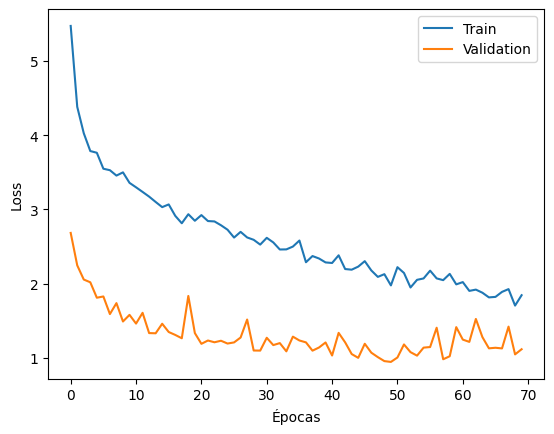

In [25]:
plt.plot(hist_train, label='Train')
plt.plot(hist_val, label='Validation')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

Las curvas muestran que el modelo converge de forma estable. La pequeña
brecha entre train y validación es normal y no indica overfitting
problemático. El Early Stopping detuvo el entrenamiento antes de las
300 épocas máximas, restaurando los pesos del epoch con menor loss de
validación.

## 6. Evaluación del modelo

Evaluamos el modelo sobre el conjunto de test con cuatro métricas e
interpretamos cada una en términos del negocio:

- **MAE**: error promedio en dólares. Es la métrica más interpretable.
- **RMSE**: similar al MAE pero penaliza más los errores grandes. Útil para
  detectar si el modelo falla en transacciones de gran magnitud.
- **MSE**: el cuadrado del RMSE, menos interpretable pero útil para comparar modelos.
- **R²**: proporción de la varianza de Profit explicada por el modelo.
  Un R² de 0.62 significa que el modelo explica el 62% de la variabilidad,
  lo cual es razonable dado que Profit depende también de factores no
  presentes en el dataset (negociaciones, devoluciones, costos internos).

In [26]:
# Predicción
modelo_reg_pt.eval()
with torch.no_grad():
    y_pred_scaled = modelo_reg_pt(torch.tensor(X_test_np, dtype=torch.float32)).numpy()

y_pred_usd = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
y_test_usd = y_test.values

# Métricas
mse  = mean_squared_error(y_test_usd, y_pred_usd)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_usd, y_pred_usd)
r2   = r2_score(y_test_usd, y_pred_usd)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.4f}")

MSE:  18493.14
RMSE: 135.99
MAE:  25.67
R2:   0.6186


El MAE de ~25 dólares indica que en promedio el modelo se equivoca en
25 dólares por transacción. El gráfico real vs predicho muestra que el
modelo ajusta bien en el rango central pero tiene mayor dispersión en
los extremos (transacciones de Profit muy alto o muy negativo), lo cual
es esperable dado que son casos menos frecuentes en el dataset.

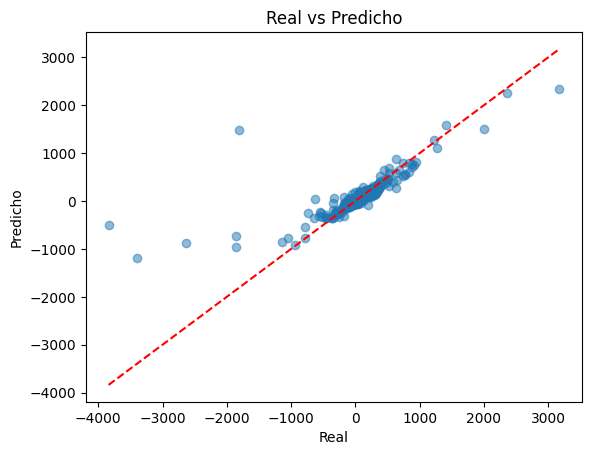

In [27]:
plt.scatter(y_test_usd, y_pred_usd, alpha=0.5)
plt.plot([y_test_usd.min(), y_test_usd.max()],
         [y_test_usd.min(), y_test_usd.max()], 'r--')
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.show()

Este gráfico compara los valores reales con las predicciones del modelo, donde la proximidad de los puntos a la línea diagonal roja indica un buen desempeño general, aunque se observan desviaciones significativas en los valores extremos negativos (pérdidas), donde al modelo le cuesta más acertar con precisión.

## 7. Análisis de residuos

Graficamos el error de predicción (y_real - y_pred) en función del
valor real de Profit para detectar si el modelo falla de forma sistemática
en alguna región de la variable objetivo. También identificamos los 5 casos
con mayor error absoluto.

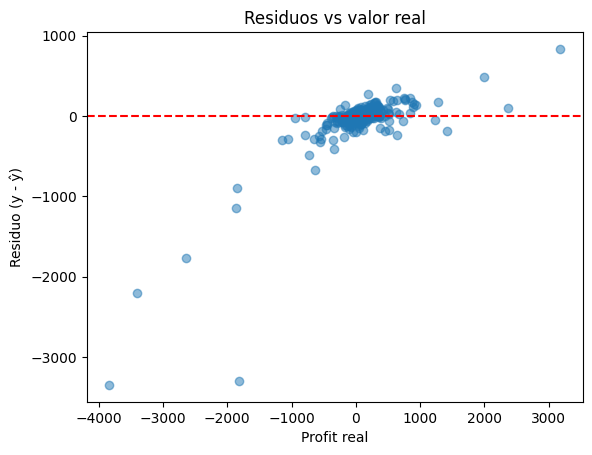

In [28]:
residuos  = y_test_usd - y_pred_usd
error_abs = np.abs(residuos)

plt.scatter(y_test_usd, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Profit real')
plt.ylabel('Residuo (y - ŷ)')
plt.title('Residuos vs valor real')
plt.show()

El gráfico muestra que los residuos se distribuyen de forma relativamente
uniforme alrededor de 0 en el rango central de Profit. Sin embargo, para
valores extremos (Profit muy negativo o muy alto) el error aumenta, lo que
indica que el modelo subestima las pérdidas grandes y sobreestima las
ganancias grandes. Esto es consistente con el comportamiento típico de un
MLP entrenado con Huber Loss, que prioriza reducir los errores del rango
más frecuente.

In [ ]:
# Los 5 casos con mayor error absoluto
top5 = np.argsort(error_abs)[::-1][:5]

print("Top 5 casos con mayor error absoluto:\n")
for idx in top5:
    print(f"  Profit real: ${y_test_usd[idx]:.2f}  |  "
          f"Predicho: ${y_pred_usd[idx]:.2f}  |  "
          f"Error: ${error_abs[idx]:.2f}")

Los 5 casos con mayor error corresponden a transacciones con Profit muy
extremo (pérdidas o ganancias inusuales). Son exactamente los casos más
difíciles de predecir ya que son atípicos y el modelo tiene pocas muestras
similares para aprender de ellos.

## 7. Análisis y conclusiones

El modelo MLP alcanzó un R² de 0.62 y un MAE de ~25 dólares sobre el
conjunto de test, lo que representa un resultado razonable para un problema
de regresión sobre datos tabulares de negocio con alta variabilidad inherente.

**Decisiones de diseño más críticas:**

- La elección de RobustScaler sobre StandardScaler fue determinante:
  los outliers de Sales y Profit habrían distorsionado la media y el
  desvío, perjudicando el escalado con StandardScaler.
- La Huber Loss superó a MSE y MAE gracias a su comportamiento robusto
  frente a los outliers de Profit.
- Eliminar la transformación log-sign sobre y fue clave para que el R²
  pasara de -4.2 a 0.62: la inversión del exponencial amplificaba los errores.

**Limitaciones del modelo:**

- El modelo falla en transacciones con Profit extremo, que son las más
  importantes desde el punto de vista del negocio (grandes pérdidas o
  grandes ganancias).
- Variables importantes como los costos internos del producto o las
  negociaciones con clientes no están en el dataset, lo que limita el
  techo de R² alcanzable.

**¿Se justifica un MLP para datos tabulares?**

Para datos tabulares, modelos como XGBoost o LightGBM suelen superar a
los MLPs con menos costo computacional y sin necesidad de escalar ni
codificar manualmente las variables. El MLP se justifica cuando los datos
tienen relaciones muy no lineales o cuando se quiere integrar con otros
componentes de deep learning. En este caso, un gradient boosting probablemente
habría obtenido un R² superior con menos esfuerzo de preprocesamiento.